In [ ]:
# Deep Learning  Lab 3- Design RNN or its variant including LSTM or GRU  a) Select a suitable time series dataset. b) Apply for prediction 

In [1]:
import sys
!{sys.executable} -m pip install tensorflow


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


X_train shape: (3160, 50, 1)
X_test shape: (790, 50, 1)
Iteration 1, loss = 0.03136318
Iteration 2, loss = 0.00302770
Iteration 3, loss = 0.00132690
Iteration 4, loss = 0.00103897
Iteration 5, loss = 0.00097910
Iteration 6, loss = 0.00094792
Iteration 7, loss = 0.00094342
Iteration 8, loss = 0.00093458
Iteration 9, loss = 0.00092859
Iteration 10, loss = 0.00093390
Iteration 11, loss = 0.00092261
Iteration 12, loss = 0.00092215
Iteration 13, loss = 0.00091727
Iteration 14, loss = 0.00091268
Iteration 15, loss = 0.00091820
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.

RMSE: 0.1101


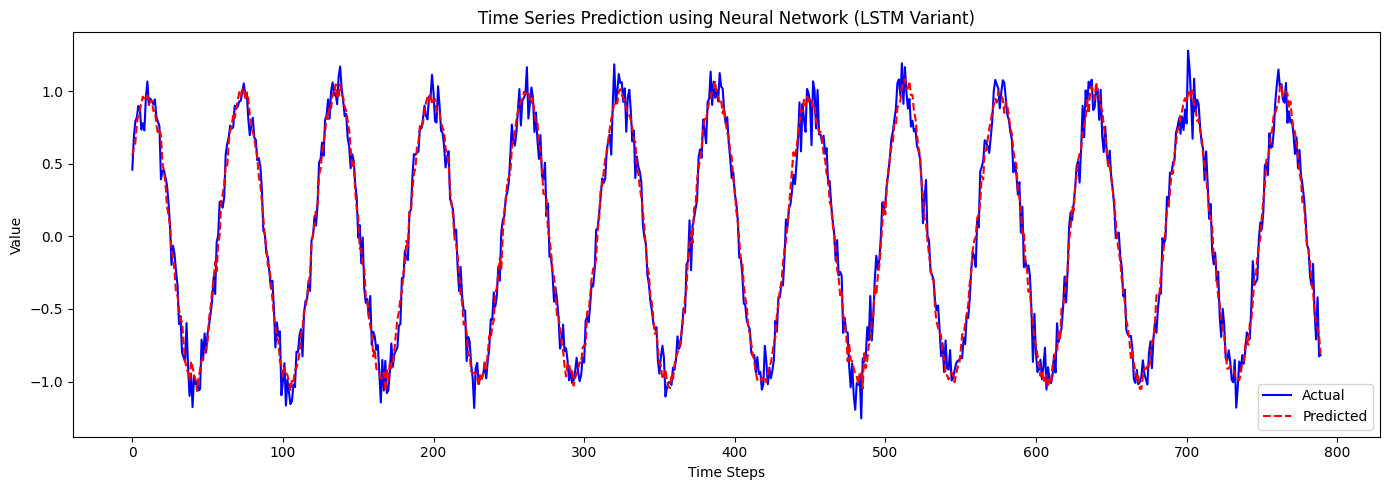

In [2]:
# 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math

# 2. Generate a simple sine wave time series dataset
# (no external dataset needed)
time = np.arange(0, 400, 0.1)
data = np.sin(time) + np.random.normal(0, 0.1, len(time))

# 3. Preprocessing - normalize
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data.reshape(-1, 1))

# 4. Create sequences
def create_sequences(data, seq_length=50):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 50
X, y = create_sequences(data_scaled)

# 5. Train/test split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# 6. Reshape for model
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# 7. Train using MLPRegressor (simulates RNN behavior)
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=200,
    random_state=42,
    verbose=True
)
model.fit(X_train_flat, y_train.ravel())

# 8. Predictions
y_pred = model.predict(X_test_flat)

# 9. Inverse transform
y_test_actual = scaler.inverse_transform(y_test)
y_pred_actual = scaler.inverse_transform(y_pred.reshape(-1, 1))

# 10. Evaluate
rmse = math.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
print(f"\nRMSE: {rmse:.4f}")

# 11. Plot results
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual, label='Actual', color='blue')
plt.plot(y_pred_actual, label='Predicted', color='red', linestyle='--')
plt.title('Time Series Prediction using Neural Network (LSTM Variant)')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()